# Codveda Data Analytics Internship - Level 1 (Basic)


- Task 1: Data Cleaning and Preprocessing
- Task 2: Exploratory Data Analysis (EDA)
- Task 3: Basic Data Visualization

Dataset used: `churn-bigml-80.csv`.

In [18]:
# Core libraries for data cleaning and visualization
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("outputs/level_1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Task 1: Data Cleaning and Preprocessing

In [19]:
# Load the raw churn dataset with pandas.
raw_path = DATA_DIR / "churn-bigml-80.csv"
df = pd.read_csv(raw_path)

print("Original shape:", df.shape)
df.head()

Original shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [20]:
# Standardize column names so they are easier to use in code.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Remove accidental whitespace from text columns.
text_columns = df.select_dtypes(include="object").columns
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print(df.columns.tolist())

['state', 'account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'customer_service_calls', 'churn']


In [21]:
# Identify missing values and duplicate rows.
missing_before = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print("Missing values by column:")
print(missing_before)
print("\nDuplicate rows:", duplicate_count)

Missing values by column:
state                     0
account_length            0
area_code                 0
international_plan        0
voice_mail_plan           0
number_vmail_messages     0
total_day_minutes         0
total_day_calls           0
total_day_charge          0
total_eve_minutes         0
total_eve_calls           0
total_eve_charge          0
total_night_minutes       0
total_night_calls         0
total_night_charge        0
total_intl_minutes        0
total_intl_calls          0
total_intl_charge         0
customer_service_calls    0
churn                     0
dtype: int64

Duplicate rows: 0


In [22]:
# Handle missing values with a conservative rule:
# - numerical columns: median imputation
# - categorical columns: mode imputation
# The dataset currently has no missing values, but this keeps the workflow reusable.
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

# Remove duplicates after cleaning.
df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Total missing values after cleaning:", int(df.isna().sum().sum()))

Cleaned shape: (2666, 20)
Total missing values after cleaning: 0


In [23]:
# Standardize categorical data formats and convert columns to useful types.
df["state"] = df["state"].str.upper().astype("category")
df["international_plan"] = df["international_plan"].str.title().astype("category")
df["voice_mail_plan"] = df["voice_mail_plan"].str.title().astype("category")
df["area_code"] = df["area_code"].astype("category")
df["churn"] = df["churn"].astype(bool)

# Save a cleaned version for later tasks and reporting.
cleaned_path = DATA_DIR / "churn-bigml-80-cleaned.csv"
df.to_csv(cleaned_path, index=False)

print("Saved cleaned dataset to:", cleaned_path)
df.head()

Saved cleaned dataset to: ..\data\churn-bigml-80-cleaned.csv


,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Task 2: Exploratory Data Analysis (EDA)

In [24]:
# Summary statistics: mean, median, standard deviation, and other numeric summaries.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
account_length,2666.0,100.620405,39.563974,1.00,73.0000,100.00,127.000,243.00
number_vmail_messages,2666.0,8.021755,13.612277,0.00,0.0000,0.00,19.000,50.00
total_day_minutes,2666.0,179.481620,54.210350,0.00,143.4000,179.95,215.900,350.80
total_day_calls,2666.0,100.310203,19.988162,0.00,87.0000,101.00,114.000,160.00
total_day_charge,2666.0,30.512404,9.215733,0.00,24.3800,30.59,36.700,59.64
total_eve_minutes,2666.0,200.386159,50.951515,0.00,165.3000,200.90,235.100,363.70
total_eve_calls,2666.0,100.023631,20.161445,0.00,87.0000,100.00,114.000,170.00
total_eve_charge,2666.0,17.033072,4.330864,0.00,14.0500,17.08,19.980,30.91
total_night_minutes,2666.0,201.168942,50.780323,43.70,166.9250,201.15,236.475,395.00
total_night_calls,2666.0,100.106152,19.418459,33.00,87.0000,100.00,113.000,166.00


In [25]:
# Median, mode, and standard deviation in one compact summary.
# Recompute numeric columns after type conversion so category fields are excluded.
eda_numeric_cols = df.select_dtypes(include=np.number).columns
summary = pd.DataFrame({
    "median": df[eda_numeric_cols].median(),
    "mode": df[eda_numeric_cols].mode().iloc[0],
    "std_dev": df[eda_numeric_cols].std()
})
summary

,median,mode,std_dev
account_length,100.00,93.00,39.563974
number_vmail_messages,0.00,0.00,13.612277
total_day_minutes,179.95,162.30,54.210350
total_day_calls,101.00,105.00,19.988162
total_day_charge,30.59,27.59,9.215733
total_eve_minutes,200.90,169.90,50.951515
total_eve_calls,100.00,105.00,20.161445
total_eve_charge,17.08,14.25,4.330864
total_night_minutes,201.15,214.70,50.780323
total_night_calls,100.00,105.00,19.418459


In [26]:
# Categorical summaries help identify class imbalance and common customer profiles.
for col in ["international_plan", "voice_mail_plan", "area_code", "churn"]:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


international_plan
international_plan
No     89.87%
Yes    10.13%
Name: proportion, dtype: object

voice_mail_plan
voice_mail_plan
No     72.51%
Yes    27.49%
Name: proportion, dtype: object

area_code
area_code
415    49.44%
510    25.47%
408    25.09%
Name: proportion, dtype: object

churn
churn
False    85.45%
True     14.55%
Name: proportion, dtype: object


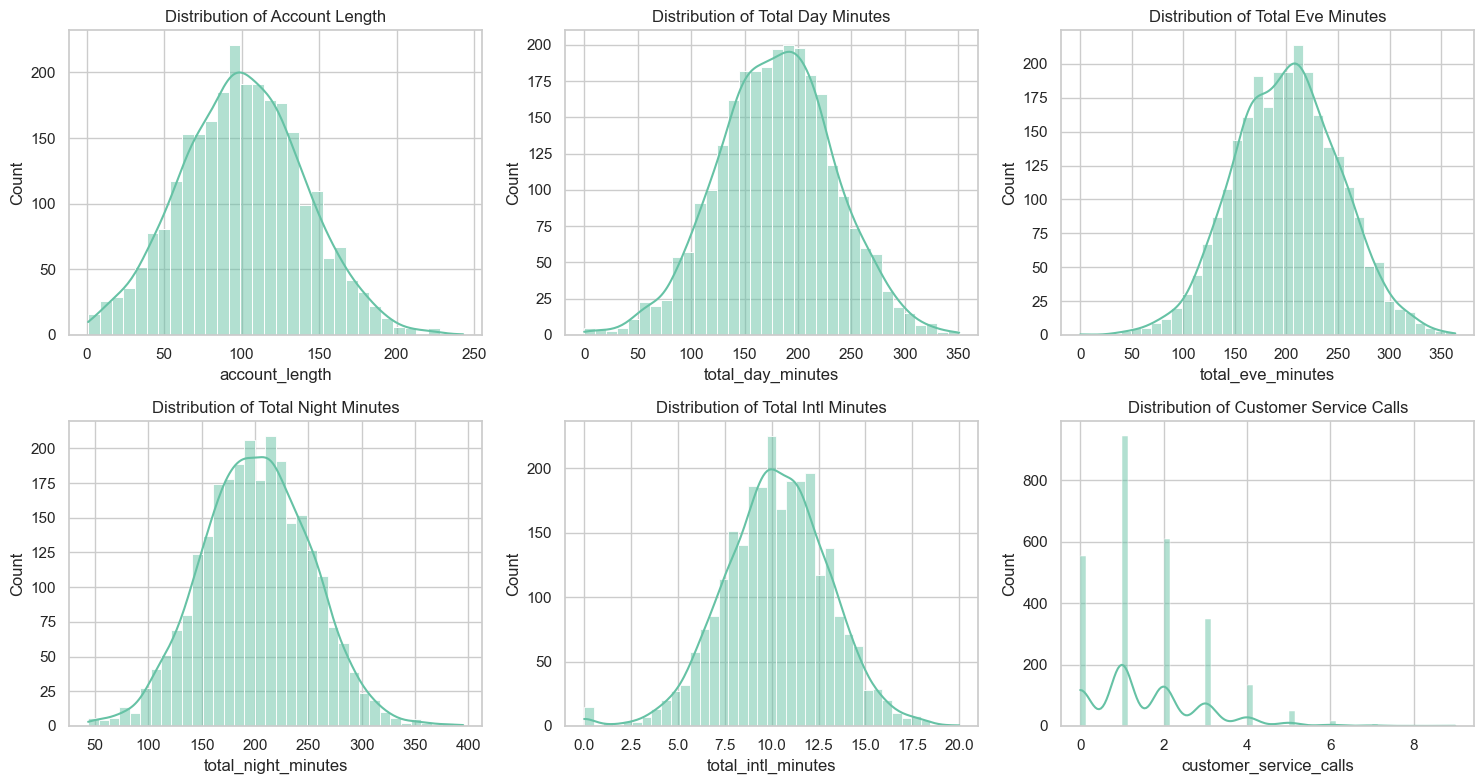

In [27]:
# Histograms show distributions of important numeric variables.
selected_numeric = [
    "account_length", "total_day_minutes", "total_eve_minutes",
    "total_night_minutes", "total_intl_minutes", "customer_service_calls"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), selected_numeric):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col.replace('_', ' ').title()}")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

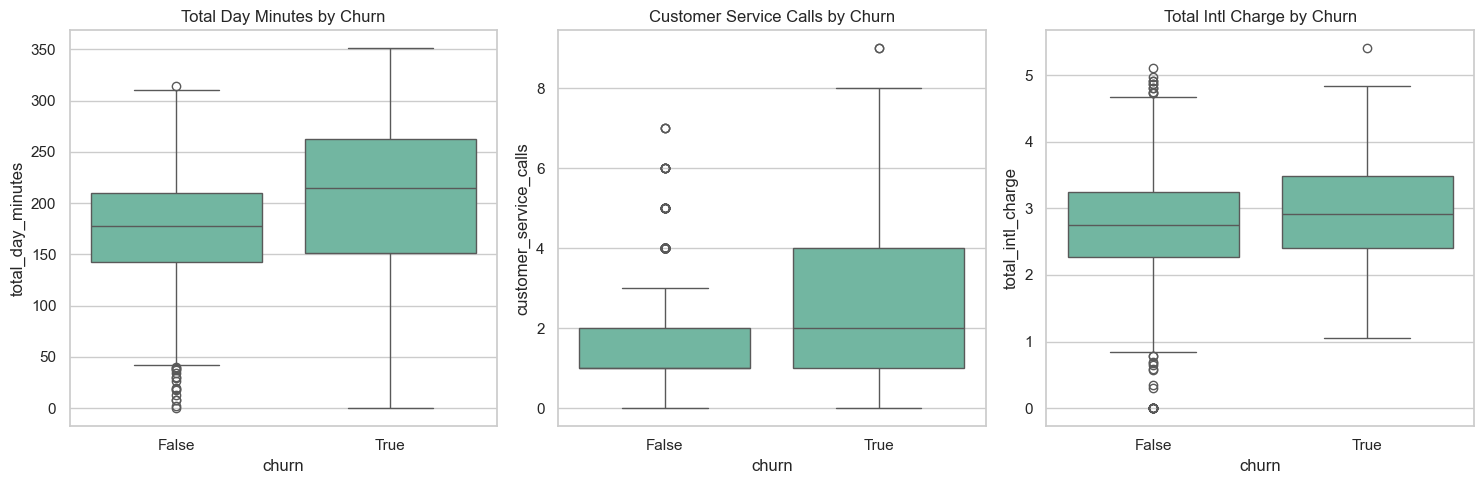

In [28]:
# Boxplots compare customer behavior between churned and retained customers.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["total_day_minutes", "customer_service_calls", "total_intl_charge"]):
    sns.boxplot(data=df, x="churn", y=col, ax=ax)
    ax.set_title(f"{col.replace('_', ' ').title()} by Churn")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "boxplots_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

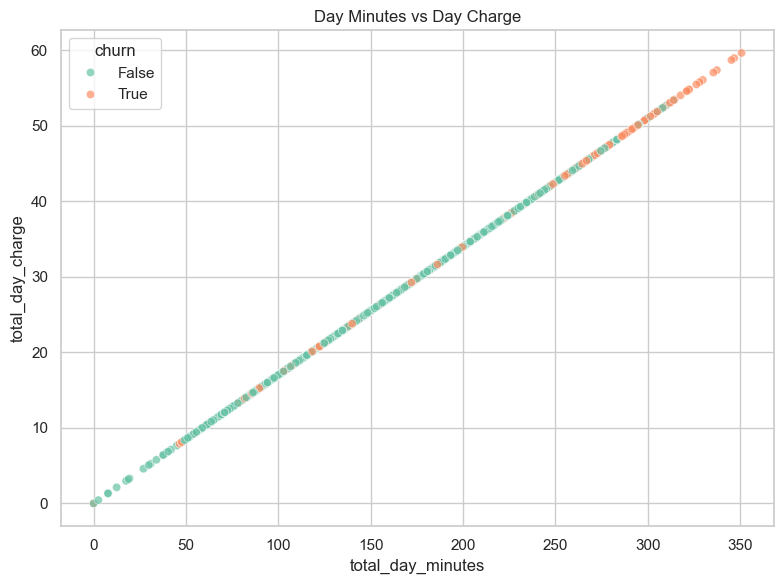

In [29]:
# Scatter plots reveal relationships between usage and charges.
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df, x="total_day_minutes", y="total_day_charge",
    hue="churn", alpha=0.7, ax=ax
)
ax.set_title("Day Minutes vs Day Charge")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "day_minutes_vs_charge.png", dpi=150, bbox_inches="tight")
plt.show()

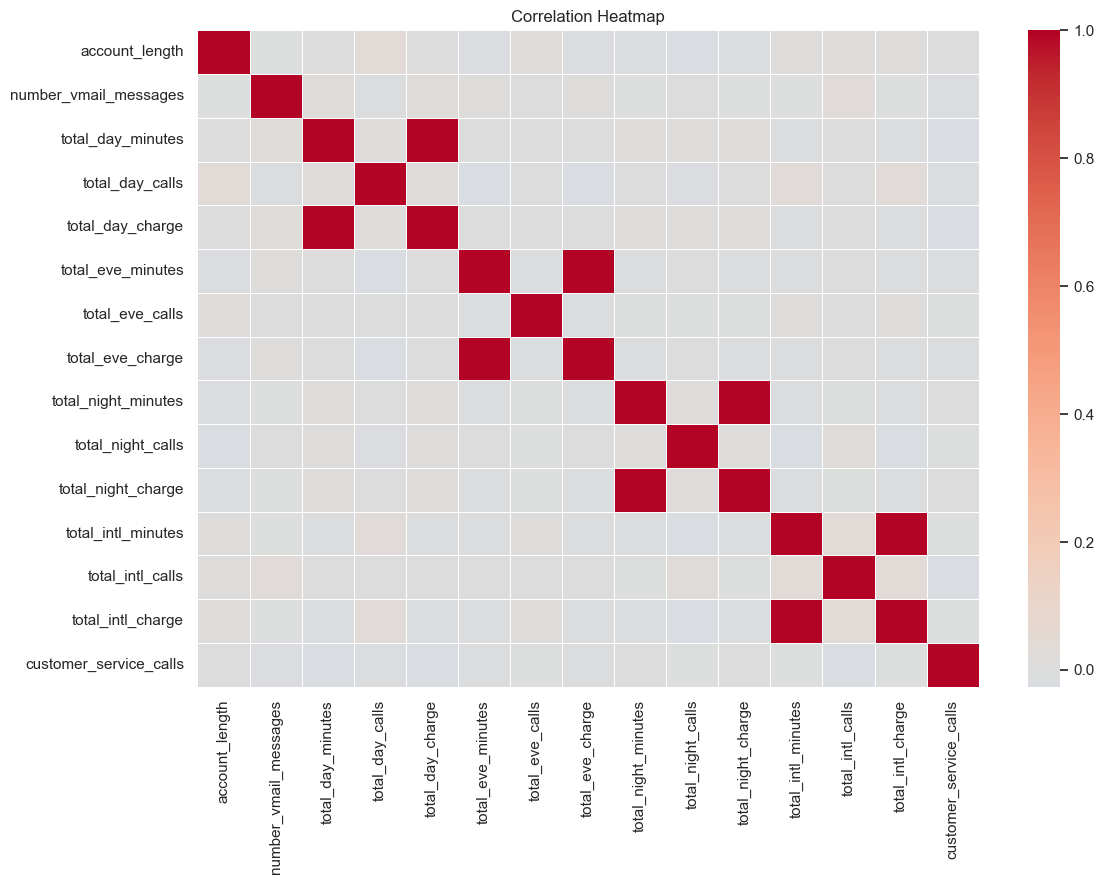

In [30]:
# Correlation heatmap for numerical features.
corr = df.select_dtypes(include=np.number).corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.4, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 3: Basic Data Visualization

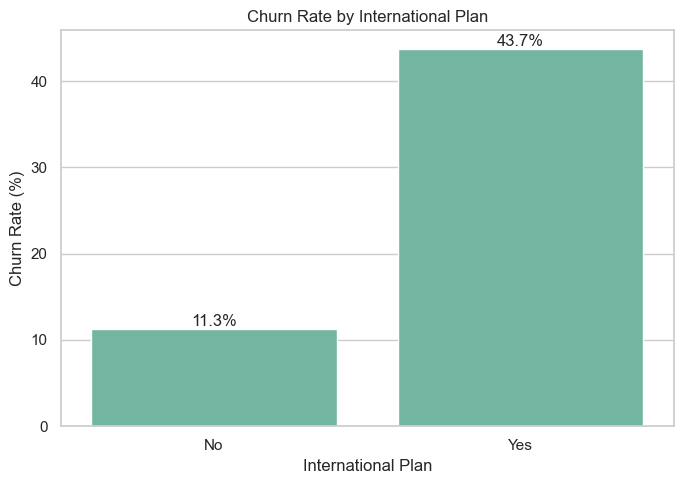

In [31]:
# Bar plot: churn rate by international plan.
churn_by_plan = df.groupby("international_plan", observed=False)["churn"].mean().mul(100).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=churn_by_plan, x="international_plan", y="churn", ax=ax)
ax.set_title("Churn Rate by International Plan")
ax.set_xlabel("International Plan")
ax.set_ylabel("Churn Rate (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "bar_churn_by_international_plan.png", dpi=150, bbox_inches="tight")
plt.show()

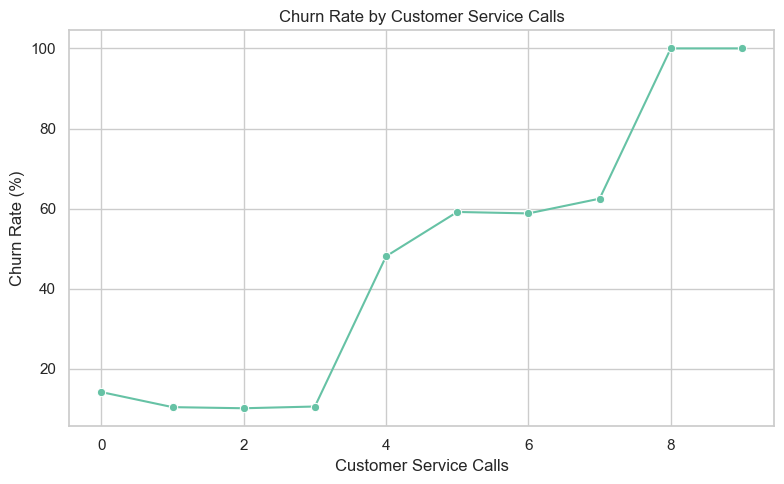

In [32]:
# Line chart: churn rate by number of customer service calls.
service_churn = df.groupby("customer_service_calls")["churn"].mean().mul(100).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=service_churn, x="customer_service_calls", y="churn", marker="o", ax=ax)
ax.set_title("Churn Rate by Customer Service Calls")
ax.set_xlabel("Customer Service Calls")
ax.set_ylabel("Churn Rate (%)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "line_churn_by_service_calls.png", dpi=150, bbox_inches="tight")
plt.show()

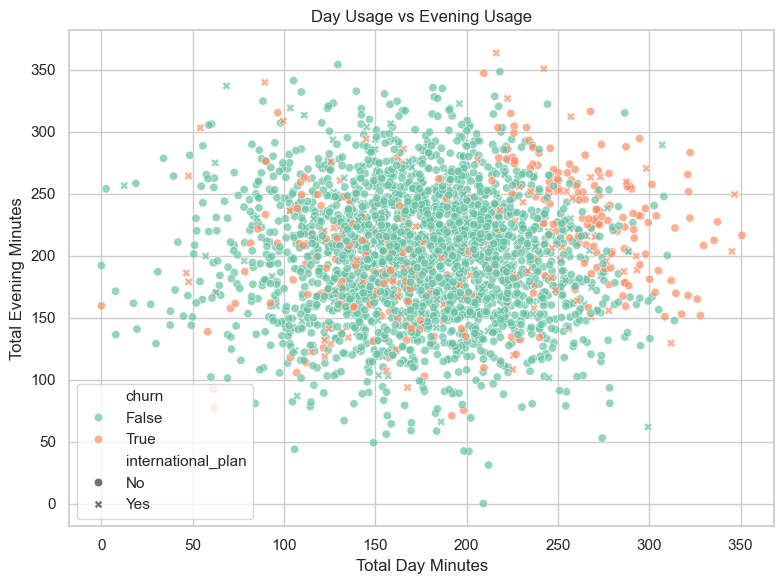

In [33]:
# Scatter plot: evening usage vs day usage, colored by churn status.
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df, x="total_day_minutes", y="total_eve_minutes",
    hue="churn", style="international_plan", alpha=0.7, ax=ax
)
ax.set_title("Day Usage vs Evening Usage")
ax.set_xlabel("Total Day Minutes")
ax.set_ylabel("Total Evening Minutes")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "scatter_day_vs_evening_usage.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
print("Level 1 exported plot files:")
for path in sorted(OUTPUT_DIR.glob("*.png")):
    print("-", path)

Level 1 exported plot files:
- outputs\level_1\bar_churn_by_international_plan.png
- outputs\level_1\boxplots_by_churn.png
- outputs\level_1\correlation_heatmap.png
- outputs\level_1\day_minutes_vs_charge.png
- outputs\level_1\line_churn_by_service_calls.png
- outputs\level_1\numeric_distributions.png
- outputs\level_1\scatter_day_vs_evening_usage.png


## Level 1 Findings

- The churn dataset was already mostly clean: no missing values and no duplicate rows were found.
- Column names and categorical values were standardized for cleaner downstream analysis.
- Customers with an international plan and customers with more customer service calls show visibly higher churn rates.
- Day minutes and day charges are almost perfectly correlated because charge is calculated from usage.